In [25]:
# All imports
import plotly.express as px
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

In [2]:
df=pd.read_csv("cell_samples.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=699, step=1)
All columns are
0 Clump
1 UnifSize
2 UnifShape
3 MargAdh
4 SingEpiSize
5 BareNuc
6 BlandChrom
7 NormNucl
8 Mit
9 Class


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Clump        699 non-null    int64 
 1   UnifSize     699 non-null    int64 
 2   UnifShape    699 non-null    int64 
 3   MargAdh      699 non-null    int64 
 4   SingEpiSize  699 non-null    int64 
 5   BareNuc      699 non-null    object
 6   BlandChrom   699 non-null    int64 
 7   NormNucl     699 non-null    int64 
 8   Mit          699 non-null    int64 
 9   Class        699 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 54.7+ KB


In [4]:
#Finding non integer value
for idx, value in enumerate(df['BareNuc']):
    try:
        int(value)
    except (ValueError, TypeError):
        print(f"Non-integer value at index {idx}: {value}")

Non-integer value at index 23: ?
Non-integer value at index 40: ?
Non-integer value at index 139: ?
Non-integer value at index 145: ?
Non-integer value at index 158: ?
Non-integer value at index 164: ?
Non-integer value at index 235: ?
Non-integer value at index 249: ?
Non-integer value at index 275: ?
Non-integer value at index 292: ?
Non-integer value at index 294: ?
Non-integer value at index 297: ?
Non-integer value at index 315: ?
Non-integer value at index 321: ?
Non-integer value at index 411: ?
Non-integer value at index 617: ?


In [5]:
# Lets replace all of them with the mode value 1
X = df
X['BareNuc'] = X['BareNuc'].replace('?', 1)
X['BareNuc'] = X['BareNuc'].astype(int)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Clump        699 non-null    int64
 1   UnifSize     699 non-null    int64
 2   UnifShape    699 non-null    int64
 3   MargAdh      699 non-null    int64
 4   SingEpiSize  699 non-null    int64
 5   BareNuc      699 non-null    int64
 6   BlandChrom   699 non-null    int64
 7   NormNucl     699 non-null    int64
 8   Mit          699 non-null    int64
 9   Class        699 non-null    int64
dtypes: int64(10)
memory usage: 54.7 KB


In [6]:
# Drop class for unsupervised learning
X = df.drop('Class', axis=1)
print(X.columns)

Index(['Clump', 'UnifSize', 'UnifShape', 'MargAdh', 'SingEpiSize', 'BareNuc',
       'BlandChrom', 'NormNucl', 'Mit'],
      dtype='object')


In [7]:
scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)
print(Xscaled)

[[ 0.20693572 -0.69999505 -0.74329904 ... -0.17966213 -0.61182504
  -0.34391178]
 [ 0.20693572  0.28384518  0.2668747  ... -0.17966213 -0.28411186
  -0.34391178]
 [-0.50386559 -0.69999505 -0.74329904 ... -0.17966213 -0.61182504
  -0.34391178]
 ...
 [ 0.20693572  2.25152563  2.28722218 ...  1.87236122  2.33759359
   0.23956962]
 [-0.14846494  1.59563215  0.94032386 ...  2.69317056  1.02674087
  -0.34391178]
 [-0.14846494  1.59563215  1.61377302 ...  2.69317056  0.37131451
  -0.34391178]]


In [8]:
# K-Means directly without feature reduction

kmeans = KMeans(n_clusters=6,random_state=42,n_init=10)

clusters = kmeans.fit_predict(Xscaled)

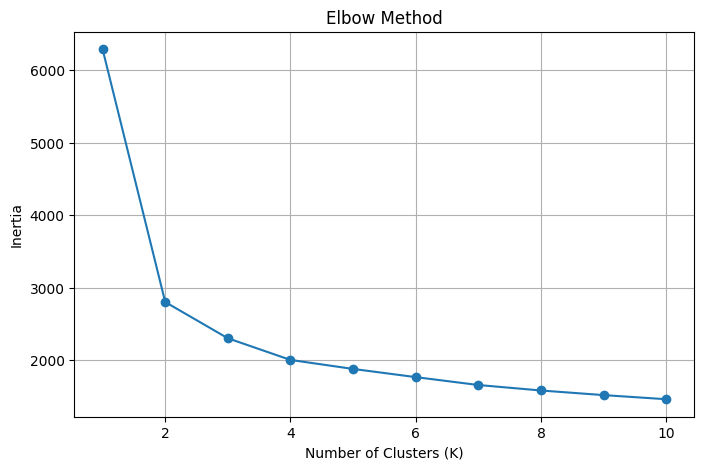

In [9]:
# Finding Best number of cluster value
inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k,random_state=42,n_init=10)
    km.fit(Xscaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [14]:
print("So the best cluster value is 2 or 3")

So the best cluster value is 2 or 3


In [34]:
pca2d = PCA(n_components=2)

Xpca2d = pca2d.fit_transform(Xscaled)

In [37]:
# K-Means on reduced PCA dataset
kmeanspca = KMeans(n_clusters=2,random_state=42,n_init=10)
clusterspca = kmeanspca.fit_predict(Xpca2d)

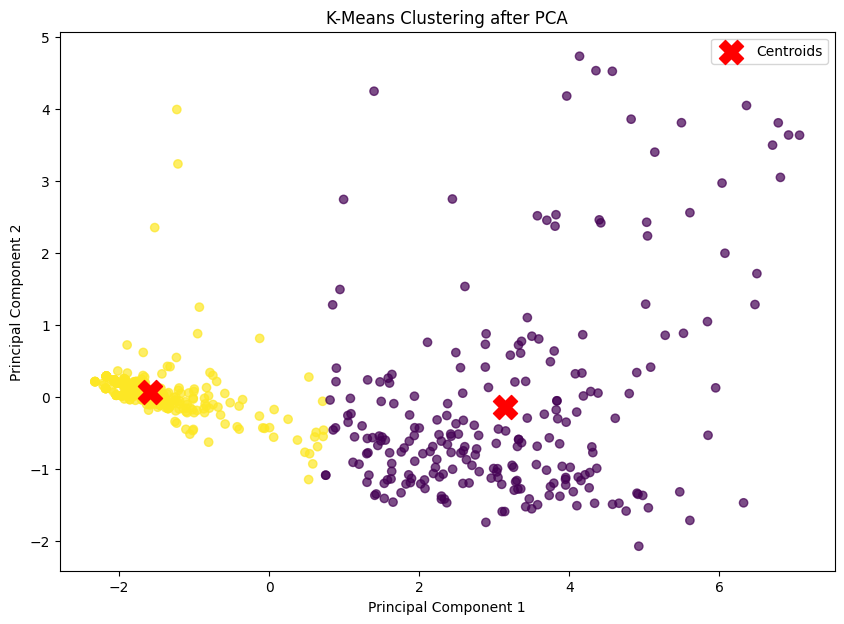

In [38]:
plt.figure(figsize=(10,7))

plt.scatter(Xpca2d[:,0],Xpca2d[:,1],c=clusterspca,cmap='viridis',alpha=0.7)

centers = kmeanspca.cluster_centers_

plt.scatter(centers[:,0],centers[:,1],marker='X',s=300,c='red',label='Centroids')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering after PCA")
plt.legend()
plt.show()

In [21]:
'''

plt.savefig("kmeanspca.png",dpi=300,bbox_inches='tight')

'''

<Figure size 640x480 with 0 Axes>

In [23]:
# Now PCA and K-Means in 3D

pca3d = PCA(n_components=3)

Xpca3d = pca3d.fit_transform(Xscaled)


In [41]:
kmeans3d = KMeans(n_clusters=3,random_state=42,n_init=10)

clusters3d = kmeans3d.fit_predict(Xpca3d)

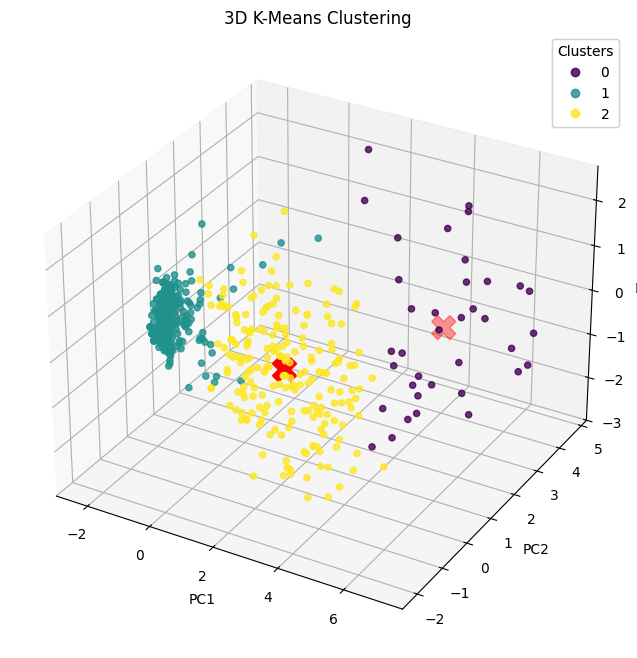

In [42]:

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(Xpca3d[:,0], Xpca3d[:,1], Xpca3d[:,2], c=clusters3d, cmap='viridis', alpha=0.8)

centers = kmeans3d.cluster_centers_

ax.scatter(centers[:,0], centers[:,1], centers[:,2], c='red', marker='X', s=300, label='Centroids')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D K-Means Clustering')

legend = ax.legend(*scatter.legend_elements(), title='Clusters')
ax.add_artist(legend)

plt.show()

In [43]:
'''

plt.savefig('kmeanspca3d.png', dpi=300, bbox_inches='tight')

'''

<Figure size 640x480 with 0 Axes>